# **Chapter 4 — Assignment 3: Manufacturing Planning**

### Course: RAS 557 — Robot Kinematics & Dynamics  
### Student: Yeshwanth Reddy Gurreddy  

---

The Libraries used in the assignment are:

In [93]:
import foldable_robotics.dxf as frd
import foldable_robotics as fr
import foldable_robotics.manufacturing as frm
from foldable_robotics.layer import Layer
from foldable_robotics.laminate import Laminate
import foldable_robotics.parts.castellated_hinge2 as frc
import shapely.geometry as sg
import dxfv2 as dv


## Step 1: Create Design Geometry

The objective of this step was to design a **multi-hinge spine mechanism** using **LibreCAD**, following the guidelines from **Chapter 53 – Creating Design Geometry in LibreCAD**.  
The spine design consists of a sequence of flexible joints connected by rigid panels, forming a continuous bendable structure that demonstrates the flexibility achievable with a **five-layer laminate**.

### Process Overview
Using **LibreCAD**, I created the 2D geometry for a modular spine made up of repeating hinge segments. The design focuses on the geometry of the hinge regions, connection spacing, and alignment between layers.  
This geometry serves as the input for the five-layer manufacturing workflow that will generate separate cut patterns for each material layer.

The main steps in creating the spine geometry were as follows:

1. **Set up the workspace**  
   - Opened **LibreCAD** and set the drawing units to **millimeters** to ensure consistency with the foldable robotics manufacturing workflow.  
   - Centered the drawing around the origin (0, 0) for proper layer alignment when imported into Python.  
   - Enabled grid snapping and object snapping to maintain hinge symmetry and consistent spacing between segments.

2. **Sketch the spine structure**  
   - Created a repeating sequence of **rectangular rigid panels** connected by **narrow hinge regions**.  
   - Each hinge region was defined as a thin strip that allows flexure, enabling the spine to bend along its length.  
   - The spacing between hinges was designed to create smooth, distributed curvature when flexed.  

3. **Add hinge and panel details**  
   - Used **construction lines** to align each hinge and ensure consistent hinge width and rotation axis positioning.  
   - Ensured that each hinge region was centered between adjacent panels and that all hinge edges were parallel.

4. **Exporting to DXF**  
   - Saved the final geometry as **spine.dxf** in **AutoCAD DXF (R15)** format for compatibility with the `foldable_robotics` library.  
   - Verified that all entities were **closed polylines** and properly assigned to their respective layers.  
   - Reopened the DXF file to confirm that scaling, units, and layer information were preserved.  

### Generated Geometry
The resulting DXF file, `spine.dxf`, represents a **multi-hinge spine mechanism** composed of several rigid panels connected by flexible hinge regions.  

<p align="center">
    <img src="Image1.png" alt="dxf">
</p>

## Step 2: Manufacturing Workflow

In this step, the **manufacturing workflow** was carried out for the **five-layer spine mechanism** using the `foldable_robotics` Python package.  
This process follows the procedure outlined in **Chapter 52 – Manufacturing Workflow**, adapted for a **five-layer laminate design** that includes alternating structural, adhesive, and flexure layers.

The goal of this stage was to process the DXF file created in LibreCAD (`spine.dxf`) and generate individual **cut patterns** for each of the five layers used in the laminate assembly.


### Adjusting Display and Curve Resolution

During the visualization and export stages, it is often useful to adjust how images and geometric curves are rendered in Jupyter Notebook.  
These display settings are provided within the `foldable_robotics` library and help improve both visualization quality and processing speed during the manufacturing workflow.

The following parameters control the display appearance and the smoothness of curves:

In [94]:
# Adjusting visualization settings in Jupyter Notebook

# Set display height for all visual outputs (in pixels)
fr.display_height = 300

# Control the global curve smoothness for shapely operations
# Lower = fewer points (faster); Higher = smoother
fr.resolution = 4


### Calculating Hinge Width for the Spine Mechanism

For **plain hinges**, the required hinge width can be calculated using a built-in convenience function available in the `foldable_robotics.manufacturing` package.  
This function estimates the hinge width based on the **desired fold angle** (range of motion) and the **laminate thickness**.

In [95]:
# Define desired fold angles for different hinge types
desired_degrees = 120  # maximum fold angle for spine joints
desired_structure = 90  # fold angle for structural joints

# Define the total laminate thickness (mm)
thickness = 1

# Calculate hinge widths using the foldable_robotics manufacturing function
plain_width = frm.plain_hinge_width(desired_degrees, thickness)
structure_width = frm.plain_hinge_width(desired_structure, thickness)

plain_width, structure_width


(1.7320508075688776, 1.0000000000000002)

### Defining Manufacturing Process Parameters

Before generating the final cut files, several **process parameters** must be defined to ensure the five-layer manufacturing workflow produces accurate and manufacturable results.  
These parameters control geometric tolerances, material spacing, adhesive behavior, and fabrication setup for the **five-layer spine design**.

In [96]:
# Manufacturing process parameters
support_width = 2  # must be larger than hinge width
kerf = 0.05  # laser kerf width (mm)
is_adhesive = [False, True, False, True, False]  # adhesive configuration per layer
arc_approx = 10  # number of segments to approximate curves
NUM_LAYERS = 5  # five-layer laminate design
bridge_thickness = 1  # support thickness for floating regions
bounding_box_padding = 10  # extra border material
jig_spacing = 10  # spacing between jig holes (mm)
jig_dia = 5  # diameter of jig holes (mm)


### Extracting the Body Geometry from the DXF

In this step, the **body geometry** of the spine design is extracted from the DXF file.  

In [97]:
# Extract the body (rigid panel) geometry from the DXF
body_vertices = dv.read_lwpolylines("jenson.dxf", layer="body", arc_approx=arc_approx)

# Display the list of vertices that define the outer boundary
body_vertices


[[(74.9, 261.4),
  (74.90000000000002, 245.9),
  (65.4, 245.9),
  (65.39999999999998, 240.9),
  (60.40000000000001, 240.9000000000001),
  (60.40000000000001, 231.9),
  (74.89999999999999, 231.9),
  (74.9, 169.5),
  (89.90590121775234, 169.5158216776121),
  (89.90590121775234, 231.9000000000001),
  (104.4000000000001, 231.9000000000003),
  (104.4, 240.9000000000003),
  (99.40000000000003, 240.9000000000002),
  (99.39999999999995, 245.9000000000002),
  (89.9, 245.9),
  (89.8999999999998, 261.4),
  (74.9, 261.4)],
 [(75.0, 150.0),
  (74.99999999999993, 134.5000000000001),
  (84.49999999999994, 134.5000000000002),
  (84.50000000000003, 129.5000000000002),
  (89.5, 129.5000000000003),
  (89.50000000000009, 120.5000000000002),
  (75.00000000000001, 120.5000000000001),
  (75.0, 70.0),
  (60.0, 70.0),
  (60.0, 120.5),
  (45.5, 120.5),
  (45.50000000000001, 129.5),
  (50.49999999999997, 129.5),
  (50.5, 134.5),
  (60.00000000000001, 134.5),
  (60.0, 150.0),
  (75.0, 150.0)],
 [(140.000098282163

### Converting Body Geometry into Shapely Polygons

We use a Python list comprehension to convert each of these point lists into an individual **Shapely polygon**:

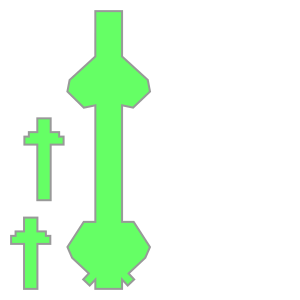

In [98]:
# Convert list of vertex lists into individual Shapely Polygon objects
# Apply .buffer(0) to fix potential topological errors (e.g., self-intersections)
body_polygons = [sg.Polygon(items).buffer(0) for items in body_vertices]

# Create a Layer object from all cleaned body polygons
body_layer = Layer(*body_polygons)
body_layer


### Extracting and Subtracting Functional Cutouts 

The `holes` layer in `spine.dxf` contains polylines that define cutouts.  
We read those polylines, convert them into Shapely polygons, collect them into a `Layer`, and then subtract that layer from the main `body_layer`. This removes the cutout areas from the structural geometry.


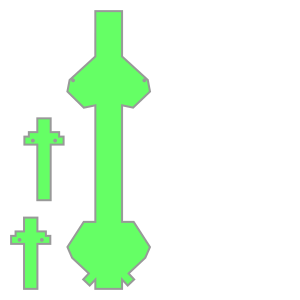

In [99]:
# Read 'holes' (cutouts) from the DXF and convert to Shapely polygons
hole_vertices = dv.read_lwpolylines("jenson.dxf", layer="holes", arc_approx=arc_approx)

circle_specs = dv.read_circles("jenson.dxf", layer="holes")
circle_polys = [
    sg.Point(center[0], center[1]).buffer(
        radius, quad_segs=16
    )  # 16 is often a good default
    for center, radius in circle_specs
]

# Build a Layer from the hole polygons
hole_layer = Layer(*[sg.Polygon(item) for item in hole_vertices + circle_polys])

# Subtract thecutouts from the body material
body_layer -= hole_layer

# Show body_layer to confirm cutouts were removed
body_layer


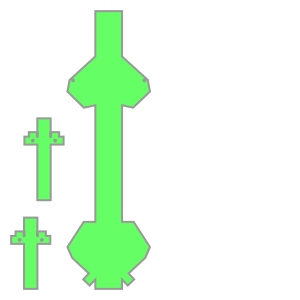

In [100]:
cut_vertices = dv.read_lines("jenson.dxf", layer="cuts")
cut_layer = Layer(*[sg.LineString(item) for item in cut_vertices])
cut_layer
cut_layer <<= 0.5
cut_layer
body_layer -= cut_layer
body_layer


### Extracting Joint Lines from the DXF

The `read_lines()` function from the DXF processing library is used to import all 2-point line segments from the `"joints"` layer.  
These line segments will later serve as the input for creating hinge patterns.

In [101]:
# Read joint line segments from the DXF file
joint_vertices = dv.read_lines("jenson.dxf", layer="joints")

# Display the imported joint vertex pairs
joint_vertices


[[(140.0046561906697, 330.8045442052427),
  (140.0046561906697, 276.0045442052428)],
 [(111.1476561906697, 304.4215442052426),
  (140.0046561906697, 276.0045442052428)],
 [(132.6978192721111, 87.34263968266673),
  (140.0046561906697, 80.50454420524274)],
 [(140.0046561906697, 80.50454420524274),
  (140.0039890020431, 145.2045348889268)],
 [(140.0039890020431, 145.2045348889268),
  (113.9407605071033, 104.901495446985)],
 [(170.0046561906697, 330.8045442052427),
  (170.0046561906697, 276.0045442052428)],
 [(198.8616561906697, 304.4215442052426),
  (170.0046561906697, 276.0045442052428)],
 [(196.0685518742361, 104.901495446985),
  (170.0053233792963, 145.2045348889268)],
 [(170.0053233792963, 145.2045348889268),
  (170.0046561906697, 80.50454420524274)],
 [(170.0046561906697, 80.50454420524274),
  (177.3114931092283, 87.34263968266673)],
 [(140.0046561906697, 80.00454420524274), (170.0, 80.0)],
 [(140.0046561906697, 145.7045442052428), (170.0, 145.7)],
 [(140.0046561906697, 194.704544205

### Converting Joint Vertices into Line Geometries and Trimming Inside the Body

Each hinge axis is represented by a straight line segment connecting two rigid panels in the spine.  
To ensure that hinge features are manufactured only within valid material regions, we then **trim the joint lines** to the intersection area with the body layer.

The complete list of `joint_vertices` is divided into two subsets:
- **Hinge joints** — lines where motion or rotation is desired (flexible sections).
- **Structural joints** — lines that define rigid folds, edges, or reinforcements with minimal flexibility.

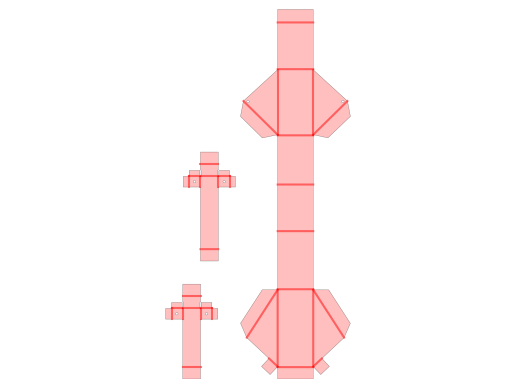

In [102]:
# Separate hinge and structural line indices
hinge_idx = [10, 11, 12, 13, 14, 15, 16, 25, 34]
structure_idx = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
]

# Create separate lists of vertex pairs for hinges and structural lines
hinge_vertices = [joint_vertices[i] for i in hinge_idx]
structure_vertices = [joint_vertices[i] for i in structure_idx]

# Convert the vertex pairs into Shapely LineString geometries and collect into Layers
hinge_lines_original_layer = Layer(*[sg.LineString(items) for items in hinge_vertices])
structure_lines_original_layer = Layer(
    *[sg.LineString(items) for items in structure_vertices]
)

hinge_lines_modified_layer = hinge_lines_original_layer & body_layer
structure_lines_modified_layer = structure_lines_original_layer & body_layer

modified_hinge_vertices = [
    list(item.coords) for item in hinge_lines_modified_layer.geoms
]
modified_structure_vertices = [
    list(item.coords) for item in structure_lines_modified_layer.geoms
]

# Plot to visualize the categorized joint lines on top of the body
hinge_lines_modified_layer.plot()
structure_lines_modified_layer.plot()
body_layer.plot()


### Generating and Applying Castellated Hinges
 
Castellated hinges are designed to maintain stiffness while still allowing controlled bending, providing improved performance over plain hinges by reducing torsion and buckling during motion.

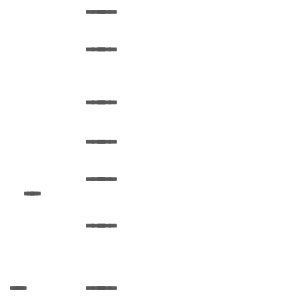

In [103]:
# Calculate castellated hinge dimensions for flexible (degree) and structural joints
castellated_deg_width, castellated_deg_gap = frm.castellated_hinge_width(
    desired_degrees, thickness
)
castellated_str_width, castellated_str_gap = frm.castellated_hinge_width(
    desired_structure, thickness
)

# Generate castellated hinge patterns for both hinge types
deg_hinges = frc.generate(castellated_deg_gap, castellated_deg_width)
str_hinges = frc.generate(castellated_str_gap, castellated_str_width)

# Create empty laminates matching the number of layers in each hinge pattern
lam_deg = Layer().to_laminate(len(deg_hinges))
lam_str = Layer().to_laminate(len(str_hinges))

# Initialize lists to store mapped hinge geometries
all_deg_hinges = []
all_str_hinges = []

# Map degree hinges along their corresponding line segments
for p3, p4 in modified_hinge_vertices:
    all_deg_hinges.append(deg_hinges.map_line_stretch((0, 0), (1, 0), p3, p4))

# Map structural hinges along their respective line segments
for p3, p4 in modified_structure_vertices:
    all_str_hinges.append(str_hinges.map_line_stretch((0, 0), (1, 0), p3, p4))

# Combine all hinge geometries into unified laminate layers
all_deg_hinges = lam_deg.unary_union(*all_deg_hinges)
all_str_hinges = lam_str.unary_union(*all_str_hinges)

all_deg_hinges


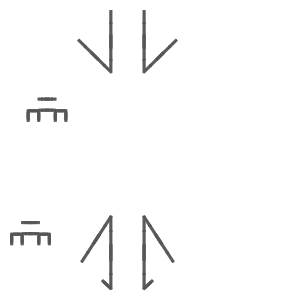

In [104]:
all_str_hinges


### Assembling the Final Five-Layer Laminate

With all hinge geometries generated and mapped along their respective joint lines, the next step is to assemble the **complete five-layer laminate** for the multi-hinge spine.

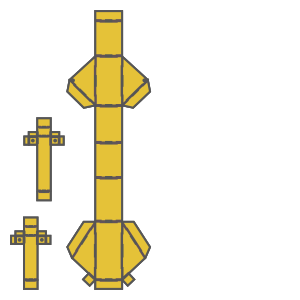

In [105]:
# Assemble the five-layer laminate for the spine
ideal_final_device = Laminate(
    body_layer, body_layer, body_layer, body_layer, body_layer
)

# Subtract both degree and structural hinge geometries from all layers
ideal_final_device -= all_deg_hinges
ideal_final_device -= all_str_hinges

# Display the final laminate with integrated hinge features
ideal_final_device


### Computing Cuttable Support and Analyzing Material Removal
Support material prevents the part from detaching prematurely during the laser-cutting process and helps maintain stability throughout fabrication.

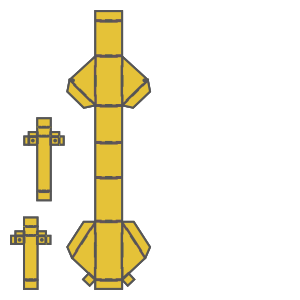

In [106]:
# Read bridge line segments from the DXF (use 'spine.dxf' in this notebook)
bridges = dv.read_lines("jenson.dxf", layer="bridge")

# Convert each 2-point segment into a LineString and place into a Layer
bridges_layer = Layer(*[sg.LineString(item) for item in bridges])

# Expand the bridge centerlines into real bridge geometry (buffer by bridge_thickness)
bridges_layer <<= bridge_thickness

# Typical mapping: [top structural, top adhesive, flexure, bottom adhesive, bottom structural]
# Bridges are placed in top and bottom structural layers (indices 0 & 4) and adhesive layers as needed.
bridges_lam = Laminate(
    bridges_layer, bridges_layer, Layer(), bridges_layer, bridges_layer
)
bridges_lam

supported_actual_device = ideal_final_device | bridges_lam
supported_actual_device

# Compute the excess material introduced by the bridges
diff = supported_actual_device - ideal_final_device

# Clean up tiny slivers due to floating point precision (tolerance = 0.1 mm)
removal = frm.cleanup(diff, 0.1)

# Expand the removal region using laser keepout so removing bridges propagates safely across layers
removal = frm.keepout_laser(removal)

actual_final_device = ideal_final_device - removal
actual_final_device


### Computing the Laser Keepout Region

With the multi-hinge spine mechanism fully designed and the five-layer laminate assembled, the next step is to compute the **laser keepout region**. 

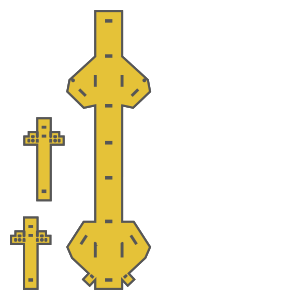

In [107]:
# Compute the laser keepout region for the final laminate
keepout = frm.keepout_laser(actual_final_device)

# Display the resulting keepout geometry
keepout


### Adding Layer Number Identification Text
To make fabrication and assembly more straightforward, each laminate layer should be clearly **labeled by number**.  

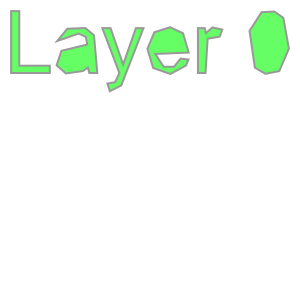

In [108]:
# Generate numbered text labels for each layer
layer_id = frm.build_layer_numbers(NUM_LAYERS, text_size=jig_dia)

# Simplify the text polygons to reduce cutting time
layer_id = layer_id.simplify(0.2)

# Display the first layer’s text geometry as an example
layer_id[0]


### Creating Alignment Holes, Sheet Boundary, and Removable Scrap

Before exporting the final cut files, we must define the **fabrication setup geometry**.  
This includes:
- Adding **alignment holes** for jig placement and layer registration.  
- Defining a **sheet boundary** that represents the area of material being used.  
- Computing the **removable scrap (web)** to determine what excess material will be cut away.

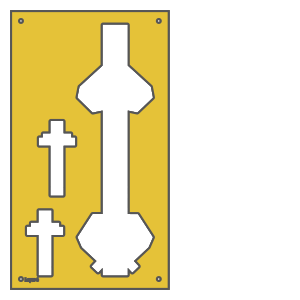

In [109]:
# --- Create alignment holes around the device bounding box ---

# Compute bounding box and dimensions of the device
(x1, y1), (x2, y2) = actual_final_device.bounding_box_coords()
w1, h1 = actual_final_device.get_dimensions()

# Round bounding box dimensions to align with the jig grid
w2 = round(w1 / jig_spacing) * jig_spacing + jig_spacing + support_width
h2 = round(h1 / jig_spacing) * jig_spacing + jig_spacing + support_width

# Adjust bounding box coordinates to center the layout
x1 -= (w2 - w1) / 2
y1 -= (h2 - h1) / 2
x2 += (w2 - w1) / 2
y2 += (h2 - h1) / 2

# Create points for four alignment holes
points = [sg.Point(x1, y1), sg.Point(x2, y1), sg.Point(x1, y2), sg.Point(x2, y2)]

# Generate circular alignment holes (buffered points)
alignment_holes_layer = Layer(*points)
alignment_holes_layer <<= jig_dia / 2
alignment_holes = alignment_holes_layer.to_laminate(NUM_LAYERS)
# --- Create outer sheet boundary ---

# Create a bounding box around the alignment holes with added padding
sheet_layer = (alignment_holes_layer << bounding_box_padding).bounding_box()
sheet = sheet_layer.to_laminate(NUM_LAYERS)

# --- Compute removable scrap (web) ---

# Determine removable scrap region based on supports and adhesives
removable_scrap = frm.calculate_removable_scrap(
    actual_final_device, sheet, support_width, is_adhesive
)

# Subtract holes and layer identifiers to define the clean web
web = (
    removable_scrap
    - alignment_holes
    - layer_id.translate(x1 + jig_dia, y1 - jig_dia / 2)
)
web


### Computing Cuttable Support and Analyzing Material Removal
After defining the laminate geometry, sheet boundary, and removable scrap, the next step is to compute **cuttable support regions**.  
Support material prevents the part from detaching prematurely during the laser-cutting process and helps maintain stability throughout fabrication.

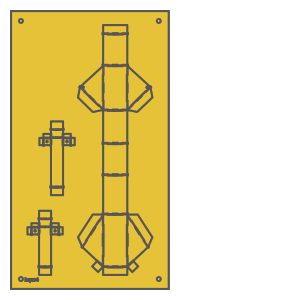

In [110]:
# Compute Cuttable Support Regions
support = frm.support(
    actual_final_device, frm.keepout_laser, support_width, support_width / 2
)

# Combine Web, Device, and Support to Visualize the Supported Design
supported_design = web | actual_final_device | support

# Compute Material Removed During Second-Pass Cut

cut_material = (keepout << kerf) - keepout

# Calculate Remaining Material After Second Cut

remaining_material = supported_design - cut_material
remaining_material


### Computing Cuttable Support and Analyzing Material Removal
Support material prevents the part from detaching prematurely during the laser-cutting process and helps maintain stability throughout fabrication.

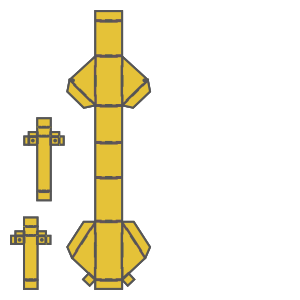

In [111]:
# Read bridge line segments from the DXF (use 'spine.dxf' in this notebook)
bridges = dv.read_lines("jenson.dxf", layer="bridge")

# Convert each 2-point segment into a LineString and place into a Layer
bridges_layer = Layer(*[sg.LineString(item) for item in bridges])

# Expand the bridge centerlines into real bridge geometry (buffer by bridge_thickness)
bridges_layer <<= bridge_thickness

# Typical mapping: [top structural, top adhesive, flexure, bottom adhesive, bottom structural]
# Bridges are placed in top and bottom structural layers (indices 0 & 4) and adhesive layers as needed.
bridges_lam = Laminate(
    bridges_layer, bridges_layer, Layer(), bridges_layer, bridges_layer
)
bridges_lam

supported_actual_device = ideal_final_device | bridges_lam
supported_actual_device

# Compute the excess material introduced by the bridges
diff = supported_actual_device - ideal_final_device

# Clean up tiny slivers due to floating point precision (tolerance = 0.1 mm)
removal = frm.cleanup(diff, 0.1)

# Expand the removal region using laser keepout so removing bridges propagates safely across layers
removal = frm.keepout_laser(removal)

actual_final_device = ideal_final_device - removal
actual_final_device


### Arranging Rigid Layers

After confirming that the cutting process correctly separates the mechanism, the next step is to isolate the **rigid layers** from the supported design and arrange them for visualization and fabrication.  

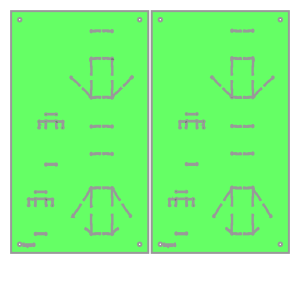

In [112]:
# Get overall dimensions and bounding box coordinates
w, h = supported_design.get_dimensions()
p0, p1 = supported_design.bounding_box_coords()

# Combine the bottom and top rigid layers and place them side-by-side
rigid_layer = supported_design[0] | (supported_design[-1].translate(w + 5, 0))
rigid_layer


Arranging Adhesive Layers

In multi-layer laminate fabrication, adhesive films often have a **backing sheet** that protects one side of the adhesive until assembly.  
When cutting these layers, the top adhesive sheet (index 3 in our design) must be **mirrored** to ensure that, after cutting and flipping, the adhesive faces the correct direction during lamination.


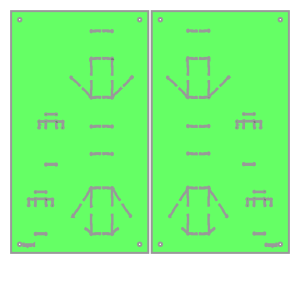

In [113]:
# Mirror the top adhesive layer (index 3) horizontally to flip the backing direction
l4 = supported_design[3].scale(-1, 1)

# Compute bounding box coordinates for repositioning
p2, p3 = l4.bounding_box_coords()

# Translate mirrored layer next to bottom adhesive layer (index 1)
l4 = l4.translate(p0[0] - p2[0] + w + 5, p0[1] - p2[1])

# Combine both adhesive layers for visualization
adhesive_layer = supported_design[1] | l4
adhesive_layer


### Assembling and Exporting the First-Pass Laminate

With all individual layers prepared — rigid, adhesive, and flexure — we can now assemble a **first-pass laminate** that represents the material configuration to be cut in the first laser pass. 

In [114]:
# Assemble the first-pass laminate including rigid, adhesive, and flexure layers
first_pass = Laminate(rigid_layer, adhesive_layer, supported_design[2])

# Export the first-pass laminate geometry to DXF format for laser cutting
first_pass.export_dxf("first_pass")


### Creating and Exporting the Final (Second-Pass) Cut File

After completing the first-pass cut , we now prepare the **final release cut** for fabrication.

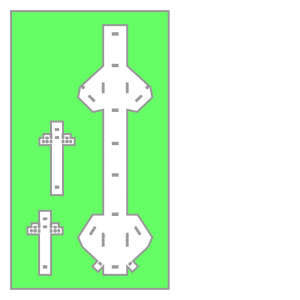

In [115]:
# Subtract the laser keepout region from the outer sheet boundary
final_cut = sheet - keepout

# Select one layer (all layers are identical in this laminate)
final_cut = final_cut[0]

# Export the final outer boundary cut to DXF format
final_cut.export_dxf("final_cut")

final_cut


## Step 3: Fabrication

The fabrication of the multi-hinge spine was performed using a ** laser cutter**, following the exported DXF files from the previous steps.  
The laser was used to cut the laminate layers for both **first-pass** and **second-pass** operations:

- **First-pass cut:** Included hinge geometries, adhesive openings, and internal flexure features.  
- **Second-pass cut:** Defined the outer perimeter of the spine mechanism, releasing it from the web.  

All five layers (two rigid, two adhesive, and one flexure) were cut sequentially and later aligned using the **jig holes** generated during the design process.  
Layer stacking and bonding were completed using a manual lamination press, ensuring even pressure distribution across the spine.


## Step 4: Physical Output

Below is the image of the fabricated **five-layer spine mechanism** after laser cutting and lamination.

![Spine Mechanism Output](image2.jpeg)

## Step 5: Evaluation & Discussion

After fabrication and testing, several important observations were made regarding the **scaling accuracy**, **kinematic performance**, **geometric design**, and **manufacturability** of the spine mechanism.

### **1. Scaling Values**
The laser-cut components closely matched the original design dimensions, with no noticeable distortion or shrinkage.  
This confirms that the **unit conversion** and **25.4× inch-to-millimeter scaling factor** were applied correctly throughout the workflow.  
Any minor variation observed was within the expected laser kerf tolerance and did not impact overall fit or assembly accuracy.

### **2. Kinematic Behavior**
The multi-hinge spine exhibited **smooth, consistent bending** across the castellated hinge regions.  
Each segment flexed predictably and symmetrically under manual actuation, producing an even curvature along the spine.  
The castellated hinge geometry effectively minimized unwanted twisting and provided a stable, repeatable range of motion.

### **3. Geometry Adjustments**
Future design iterations could include **small mounting tabs or connector slots** to simplify integration into a larger robotic assembly.  
These features would allow for easier attachment to base structures or actuators without altering the core hinge behavior.

### **4. Manufacturing Considerations**
To improve fabrication precision, the **final cut alignment** between the first-pass and second-pass laser operations should be refined. 